# 00. Initialise the notebooks

In [ ]:
import json
import numpy as np
from rasterio.transform import from_origin

## Projection and Bounding Box Config

In [18]:
from pyproj import Transformer, Geod

WGS84 = "EPSG:4326"
MGA55 = "EPSG:28355"   # GDA94 / MGA zone 55 -- metres, correct for Melbourne

g = Geod(ellps="WGS84")
lat, lon = -37.8136, 144.9631   # Sample melbourne lat/lon for testing

# Transformers for converting between WGS84 and MGA55
to_m  = Transformer.from_crs(WGS84, MGA55, always_xy=True)
to_ll = Transformer.from_crs(MGA55, WGS84, always_xy=True)

In [19]:
# The bounding box in degrees
BBOX = dict(min_lon=144.940, max_lon=144.985, min_lat=-37.830, max_lat=-37.795)
BUFFER_M = 500.0   # buffer zone around the box so outside buildings still cast in

# rasters need metres. Project the two corners to MGA55.
xs, ys = to_m.transform([BBOX["min_lon"], BBOX["max_lon"]],
                        [BBOX["min_lat"], BBOX["max_lat"]])
print(f"bounding box size (m): {max(xs)-min(xs):.0f} x {max(ys)-min(ys):.0f} m")

# Push every edge out by the buffer
minx, maxx = min(xs) - BUFFER_M, max(xs) + BUFFER_M
miny, maxy = min(ys) - BUFFER_M, max(ys) + BUFFER_M


bounding box size (m): 3877 x 3970 m


In [60]:
# Calculate size of raster: how many 2 m cells fit in the box rounded up to the next whole number
CELL     = 2.0  # Cell size of every raster layer in metres
w = int((maxx - minx) / CELL)
h = int((maxy - miny) / CELL)

# Update maxx and miny so it matches the raster size exactly
maxx = minx + w * CELL
miny = maxy - h * CELL

In [64]:
# Create the transform for the raster
transform = from_origin(minx, maxy, CELL, CELL)
print(f"transform:\n{transform}")

print(f"\ngrid: {w} x {h} cells  ({w*CELL:.0f} x {h*CELL:.0f} m)")
# Corners back in lat/lon.
print(f"SW corner {[round(v, 5) for v in to_ll.transform(minx, miny)]}")
print(f"NE corner {[round(v, 5) for v in to_ll.transform(maxx, maxy)]}")

transform:
| 2.00, 0.00, 318211.02|
| 0.00,-2.00, 5815517.47|
| 0.00, 0.00, 1.00|

grid: 2438 x 2485 cells  (4876 x 4970 m)
SW corner [144.9342, -37.8344]
NE corner [144.99079, -37.79059]


In [ ]:
# Initialise a config dictionary to save the parameters for other notebooks
CONFIG = {
    "crs": {
        "wgs84": WGS84,
        "mga55": MGA55
    },
    "bbox": BBOX,
    "box_center": {"lat": lat, "lon": lon},
    "buffer_m": BUFFER_M,
    "grid": {
        "maxx": maxx, "minx": minx, "maxy": maxy, "miny": miny,  # in MGA55 metres
        "width": w, "height": h,                                 # in pixels
    },
    "canopy": {
        "height": 8.0
    }
}

# Save the config to a JSON file so other notebooks can read it
CONFIG_PATH = "config.json"
with open(CONFIG_PATH, "w") as f:
    json.dump(CONFIG, f, indent=4)

## Datasets

### City of Melbourne source polygons

Two datasets from City of Melbourne's open data portal:
| what | dataset id | why |
|---|---|---|
| building outlines | `building-outlines-2015` | carries `ovlhgt_ahd` / `base_ahd`, so every footprint has a height |
| tree canopy | `tree-canopies-2021-urban-forest` | polygons only, no height we assign a nominal 8 m later |

Buildings are fetched over the **buffered** box and canopy only over the bare bbox 

In [25]:
import os, json, urllib.parse, urllib.request
COM = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/{}/exports/geojson"

DATA = "data"  # where all the data files are stored
os.makedirs(DATA, exist_ok=True)

# The padded grid corners, back in lat/lon. Buildings this far out still cast into the box.
sw_lon, sw_lat = to_ll.transform(minx, miny)
ne_lon, ne_lat = to_ll.transform(maxx, maxy)

In [26]:
BUILDING_DATA = {
    "name": "buildings",
    "dataset_id": "building-outlines-2015",
    "box": (sw_lat, sw_lon, ne_lat, ne_lon)
}
CANOPY_DATA = {
    "name": "canopy",
    "dataset_id": "tree-canopy-2015",
    "box": (BBOX["min_lat"], BBOX["min_lon"], BBOX["max_lat"], BBOX["max_lon"])
}


for data in [BUILDING_DATA, CANOPY_DATA]:
    out_path = os.path.join(DATA, f"{data['name']}.geojson")
    if os.path.exists(out_path) and os.path.getsize(out_path) > 1000:
        print(f"cached   {data['name']}.geojson  ({os.path.getsize(out_path)/1e6:.1f} MB)")
        continue

    filters = "in_bbox(geo_point_2d,{},{},{},{})".format(*data["box"])
    url = COM.format(data["dataset_id"]) + "?" + urllib.parse.urlencode({"where": filters})

    print(f"fetching {data['name']} ...")
    urllib.request.urlretrieve(url, out_path)
    print(f"done     {data['name']}.geojson  ({os.path.getsize(out_path)/1e6:.1f} MB)")

cached   buildings.geojson  (12.8 MB)
cached   canopy.geojson  (106.9 MB)


In [27]:
# What we actually got.
for data in (BUILDING_DATA, CANOPY_DATA):
    out_path = os.path.join(DATA, f"{data['name']}.geojson")
    feats = json.load(open(out_path))["features"]
    print(f"\n{os.path.basename(out_path)}: {len(feats)} features")
    print(f"  fields: {list(feats[0]['properties'])}")


buildings.geojson: 12884 features
  fields: ['geo_point_2d', 'geom_type', 'ovlhgt_ahd', 'suburb', 'struct_id', 'base_ahd']

canopy.geojson: 23578 features
  fields: ['geo_point_2d']


## Rasterising Polygons

In [32]:
import shapely
from shapely.geometry import shape
from rasterio.features import rasterize

# Reproject a whole geometry's coordinates at once, lon/lat -> metres.
def to_mga(geom):
    return shapely.transform(geom, lambda c: np.column_stack(to_m.transform(c[:, 0], c[:, 1])))

def burn(path, height_fn):
    """GeoJSON polygons -> a (h, w) float32 raster of heights."""
    feats = json.load(open(path))["features"]
    shapes, skipped = [], 0
    for f in feats:
        if not f.get("geometry"):
            skipped += 1; continue
        hgt = height_fn(f["properties"])
        if hgt is None or hgt <= 0:
            skipped += 1; continue
        shapes.append((to_mga(shape(f["geometry"])), float(hgt)))

    # rasterize overwrites, it has no "keep the max". Shortest first so the tallest wins.
    shapes.sort(key=lambda s: s[1])
    a = rasterize(shapes, out_shape=(h, w), transform=transform, dtype="float32", fill=0.0)
    print(f"{path}  {len(shapes)} polys ({skipped} skipped)  "
          f"{(a>0).mean()*100:.1f}% cover  max {a.max():.1f} m")
    return a

# Buildings carry real heights: roof AHD minus ground AHD.
def building_height(p):
    o, b = p.get("ovlhgt_ahd"), p.get("base_ahd")
    return None if o is None or b is None else max(0.0, o - b)

In [47]:
CANOPY_HEIGHT = 8.0

dsm = burn("data/buildings.geojson", building_height)
canopy = burn("data/canopy.geojson", lambda p: CANOPY_HEIGHT) # canopy has no height field

OUT_DIR = "out/rasters"
os.makedirs(OUT_DIR, exist_ok=True)

np.save(f"{OUT_DIR}/dsm_buildings.npy", dsm)
np.save(f"{OUT_DIR}/dsm_canopy.npy", canopy)

data/buildings.geojson  12882 polys (2 skipped)  23.1% cover  max 298.0 m
data/canopy.geojson  23578 polys (0 skipped)  7.5% cover  max 8.0 m


### Define Lookups

In [48]:
# Helper to transform from x, y (metres) to row, col (pixels)
def rc(x, y):
    """Row 0 is the NORTH edge, so it counts down from maxy."""
    return (maxy - np.asarray(y)) / CELL, (np.asarray(x) - minx) / CELL

def xy(row, col):
    """(row, col) -> metres, top-left corner of that cell."""
    return minx + np.asarray(col) * CELL, maxy - np.asarray(row) * CELL

## Plotting Rasters

In [49]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


VIEW_M = 3000  # how much city to show, metres across
# Centre the view on the middle of the bounding box
cx, cy = to_m.transform((BBOX["min_lon"] + BBOX["max_lon"]) / 2,
                        (BBOX["min_lat"] + BBOX["max_lat"]) / 2)
cr, cc = rc(cx, cy)
half = int(VIEW_M / CELL / 2)
r0, r1 = int(cr) - half, int(cr) + half
c0, c1 = int(cc) - half, int(cc) + half

TREE_COLOR = ListedColormap(["#4bbf62"])
TREE_ALPHA = 0.65

dsm_view = dsm[r0:r1, c0:c1]
canopy_view = np.ma.masked_where(canopy[r0:r1, c0:c1] <= 0, canopy[r0:r1, c0:c1])

def draw(ax, extent):
    """Both layers, into whichever coordinate system `extent` describes."""
    ax.imshow(dsm_view, cmap="magma", vmax=120, interpolation="nearest", extent=extent)
    ax.imshow(canopy_view, cmap=TREE_COLOR, alpha=TREE_ALPHA, interpolation="nearest", extent=extent)

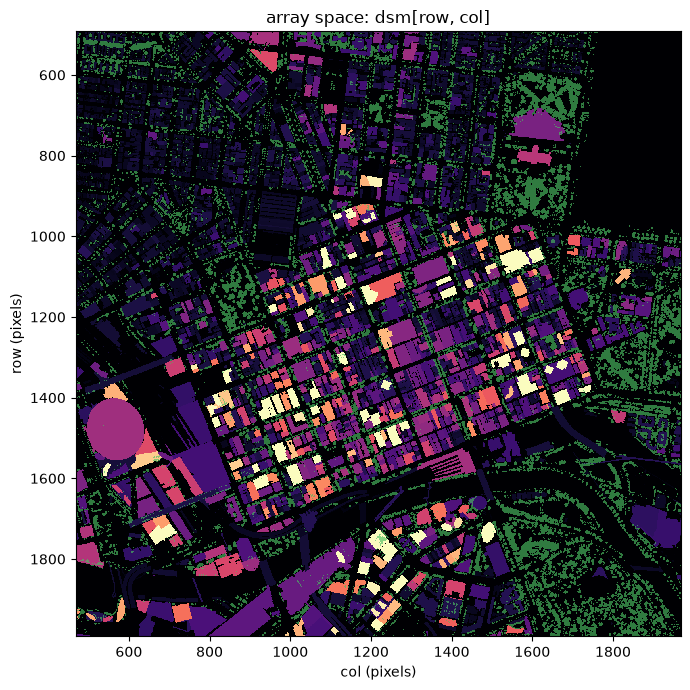

In [53]:
fig, ax = plt.subplots(figsize=(8, 7))
# What numpy sees. Rows count down from the north edge.
draw(ax, [c0, c1, r1, r0])
ax.set_xlabel("col (pixels)")
ax.set_ylabel("row (pixels)")
ax.set_title("array space: dsm[row, col]")
fig.tight_layout()

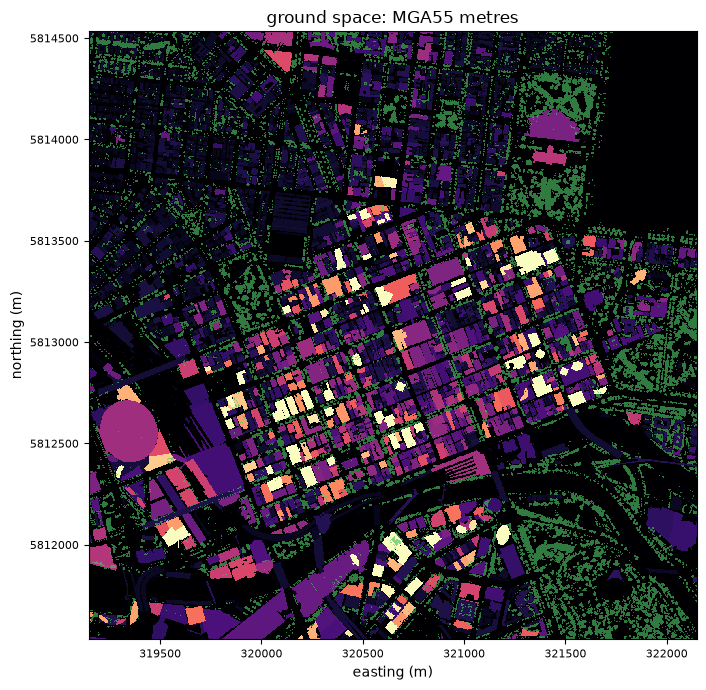

In [54]:
fig, ax = plt.subplots(figsize=(8, 7))
# The same pixels on the ground. Northing counts up.
x0, x1 = minx + c0 * CELL, minx + c1 * CELL
y0, y1 = maxy - r0 * CELL, maxy - r1 * CELL
draw(ax, [x0, x1, y1, y0])
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
ax.set_title("ground space: MGA55 metres")
ax.ticklabel_format(style="plain", useOffset=False)   # stop the 1e6 offset
ax.tick_params(labelsize=8)
fig.tight_layout()